In [1]:
import matplotlib.pyplot as plt
import numpy as np
from typing import List

from model.classification import ClassificationType, DatasetType
from src.data_manager import DataManager

In [2]:
number_of_babies = DataManager.count_number_of_images(ClassificationType.BABIES)
number_of_men = DataManager.count_number_of_images(ClassificationType.MEN)
number_of_women = DataManager.count_number_of_images(ClassificationType.WOMEN)
number_of_none = DataManager.count_number_of_images(ClassificationType.NONE)

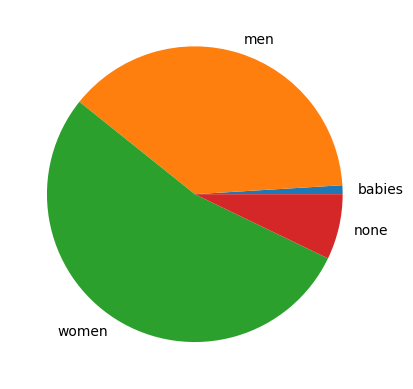

[2131, 84437, 118168, 15769]


In [3]:
number_of_classes = [
    number_of_babies,
    number_of_men,
    number_of_women,
    number_of_none
]
labels = [class_type.value for class_type in ClassificationType.get_all_types()]

plt.pie(number_of_classes, labels=labels)
plt.show()
print(number_of_classes)

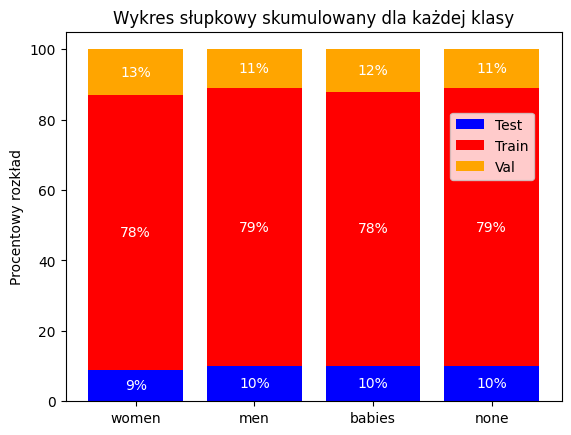

In [4]:
def get_percentage_list(x: int, y:int, z:int):
    sum_elements = x + y + z
    x_per = int(x * 100 / sum_elements)
    y_per = int(y * 100 / sum_elements)
    z_per = 100 - (x_per + y_per)
    return [x_per, y_per, z_per]

babies_test = DataManager.count_number_of_images(ClassificationType.BABIES, DatasetType.TEST)
babies_train = DataManager.count_number_of_images(ClassificationType.BABIES, DatasetType.TRAIN)
babies_val = DataManager.count_number_of_images(ClassificationType.BABIES, DatasetType.VAL)
babies_size = get_percentage_list(babies_test, babies_train, babies_val)

women_test = DataManager.count_number_of_images(ClassificationType.WOMEN, DatasetType.TEST)
women_train = DataManager.count_number_of_images(ClassificationType.WOMEN, DatasetType.TRAIN)
women_val = DataManager.count_number_of_images(ClassificationType.WOMEN, DatasetType.VAL)
women_size = get_percentage_list(women_test, women_train, women_val)

men_test = DataManager.count_number_of_images(ClassificationType.MEN, DatasetType.TEST)
men_train = DataManager.count_number_of_images(ClassificationType.MEN, DatasetType.TRAIN)
men_val = DataManager.count_number_of_images(ClassificationType.MEN, DatasetType.VAL)
men_size = get_percentage_list(men_test, men_train, men_val)

none_test = DataManager.count_number_of_images(ClassificationType.NONE, DatasetType.TEST)
none_train = DataManager.count_number_of_images(ClassificationType.NONE, DatasetType.TRAIN)
none_val = DataManager.count_number_of_images(ClassificationType.NONE, DatasetType.VAL)
none_size = get_percentage_list(none_test, none_train, none_val)


class_types = ["women", "men", "babies", "none"]
sizes = {
    "women": women_size,
    "men": men_size,
    "babies": babies_size,
    "none": none_size
}
colors = ["blue", "red", "orange"]
labels = ["Test", "Train", "Val"]

fig, ax = plt.subplots()
x_positions = range(len(class_types))

for x, class_type in enumerate(class_types):
    bottom = 0
    for i, (value, color, label) in enumerate(zip(sizes[class_type], colors, labels)):
        ax.bar(x, value, color=color, label=label if x == 0 else "", bottom=bottom)
        ax.text(x, bottom + value / 2, f"{value}%", ha='center', va='center', color='white', fontsize=10)
        bottom += value
        
ax.set_xticks(x_positions)
ax.set_xticklabels(class_types)
ax.set_ylabel('Procentowy rozkład')
ax.set_title('Wykres słupkowy skumulowany dla każdej klasy')
ax.legend(bbox_to_anchor=(0.86, 0.8), loc='upper center', ncol=1)

plt.show() 

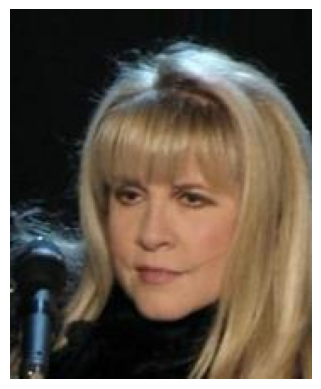

In [9]:
# a = DataManager.get_image(ClassificationType.WOMEN, DatasetType.VAL, "180003.jpg")
a = DataManager.get_image()
plt.axis('off')
plt.imshow(a)
plt.show()

In [10]:
test = DataManager.get_all_images(ClassificationType.BABIES)
print(test.shape)

(2131, 200, 200, 3)


In [11]:
test2 = DataManager.get_all_images(ClassificationType.MEN)
print(test.shape)

(2131, 200, 200, 3)
